# Assignment 4: Regularization

#hi

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

**The idea of adding a penalty is to stop the model from getting too complicated. If we only minimize MSE, the model might use very large coefficients to fit every small detail in the data, which leads to overfitting. The penalty makes large coefficients “costly,” so the model keeps them smaller. This helps the model focus on the main patterns instead of noise and improves performance on new data.**

2. How does regularization provide a way of exploring the bias-variance trade-off?

**Regularization helps us control the balance between overfitting and underfitting. When the penalty α is small, the model fits the data very closely, which means low bias but high variance. When α is large, the model becomes simpler, which increases bias but lowers variance. By trying different α values, we can find the best balance where the model is not too complex but still captures important patterns.**

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

**Ridge regression shrinks all coefficients toward zero but keeps every variable in the model. LASSO can shrink some coefficients all the way to zero, which means it removes those variables completely. Because of this, LASSO does feature selection and creates a simpler model. Ridge keeps all variables but just reduces their impact.**

4. How do we typically scale variables for use in regularized regression? Why?

**We scale variables so that they are all on the same level before applying regularization. This is important because the penalty depends on the size of the coefficients. If one variable has much larger values than another, it could unfairly affect the results. Scaling makes sure each variable is treated equally and the model works correctly.**

5. How is the penalty $\alpha$ typically selected?

**We usually choose α using cross validation. This means we try many different α values, train the model, and check how well it predicts on new data. The α that gives the lowest prediction error is chosen. This helps us pick a value that works best for unseen data.**

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**No, we do not include the penalty when calculating cross validated MSE. Cross validation is meant to measure how well the model predicts new data, so we only look at the prediction error. The penalty is only used during training to control the size of the coefficients.**

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [ ]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 126 (delta 0), reused 0 (delta 0), pack-reused 124 (from 2)
Receiving objects: 100% (126/126), 12.31 MiB | 12.37 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [ ]:
#Q2.1

import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')

df = df.drop(columns=['Unnamed: 0'])

df['Age'] = 2024 - df['Make_Year']

X = df[['Mileage_Run', 'Age']]
y = df['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [ ]:
#Q2.2

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

for name, coef in zip(feature_names, model.coef_):
    print(name, coef)

Mileage_Run 668616.517209674
Age -184194.14613723248
Mileage_Run^2 -149467.87417613144
Mileage_Run Age -1251592.3408260453
Age^2 215639.8787572434
Mileage_Run^3 -65144.89659917474
Mileage_Run^2 Age 283339.15222242544
Mileage_Run Age^2 528082.863474972
Age^3 -138937.02579369987


**Q2.2 Answer:**

**The interaction between Mileage_Run and Age is negative. This means that when both mileage and age increase together, the price decreases more than expected from their individual effects. In simple terms, older cars with higher mileage lose value faster.**

In [ ]:
#Q2.3

from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)

lasso.fit(X_scaled, y)

print("Best alpha:", lasso.alpha_)

Best alpha: 483.2930238571752


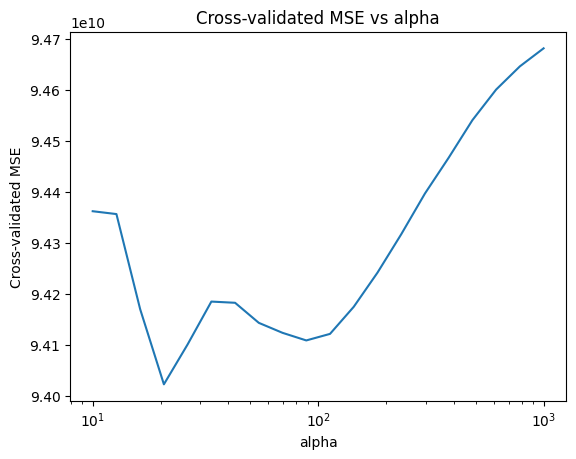

In [ ]:
#Q2.4

import matplotlib.pyplot as plt

mse_mean = lasso.mse_path_.mean(axis=1)

plt.plot(alphas, mse_mean)
plt.xscale('log')

plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-validated MSE vs alpha')

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.408e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.686e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.202e+11, tolerance: 1.316e

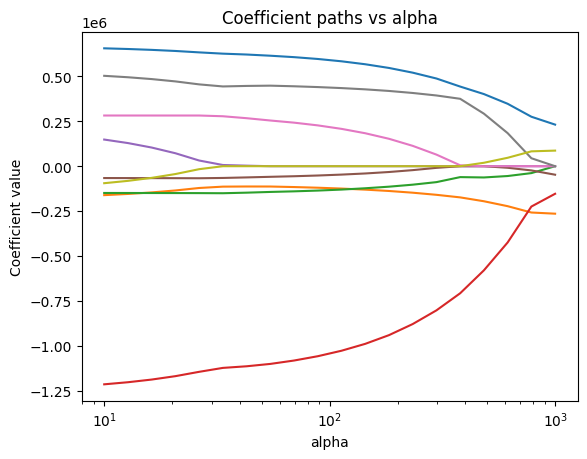

In [ ]:
#Q2.5

from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_scaled, y)
    coefs.append(lasso_temp.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('Coefficient paths vs alpha')

plt.show()

In [ ]:
#Q2.6

coefs = lasso.coef_

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

selected = feature_names[coefs != 0]

prop_zero = np.mean(coefs == 0)

print("Selected features:", selected)
print("Proportion set to zero:", prop_zero)

Selected features: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Mileage_Run Age^2'
 'Age^3']
Proportion set to zero: 0.3333333333333333


**Q2.6 Answer:**

**The selected features are Mileage_Run, Age, Mileage_Run², Mileage_Run × Age, Mileage_Run × Age², and Age³. About 33% of the features are set to zero, meaning LASSO removes less important variables and simplifies the model.**

In [ ]:
#Q2.7

for name, lin, las in zip(feature_names, model.coef_, lasso.coef_):
    print(f"{name}: Linear={lin:.2f}, Lasso={las:.2f}")

Mileage_Run: Linear=668616.52, Lasso=401025.26
Age: Linear=-184194.15, Lasso=-194803.12
Mileage_Run^2: Linear=-149467.87, Lasso=-62539.29
Mileage_Run Age: Linear=-1251592.34, Lasso=-578788.66
Age^2: Linear=215639.88, Lasso=-0.00
Mileage_Run^3: Linear=-65144.90, Lasso=-0.00
Mileage_Run^2 Age: Linear=283339.15, Lasso=0.00
Mileage_Run Age^2: Linear=528082.86, Lasso=292015.03
Age^3: Linear=-138937.03, Lasso=19133.91


**Q2.7 Answer:**

**Compared to linear regression, the LASSO coefficients are generally smaller because of the penalty. Some coefficients are also set exactly to zero, such as Mileage_Run³ and Mileage_Run² × Age, which means those features are removed from the model.**

**No coefficients increase in magnitude from linear regression to LASSO. Most coefficients keep the same sign, although a few may change slightly due to relationships between variables.**

**Overall, LASSO creates a simpler model by shrinking coefficients and removing less important features.**

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
#Q3.1

import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/heart_failure_clinical_records_dataset.csv')

X_cont = df[['age', 'ejection_fraction', 'serum_creatinine']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_cont)

scaler_cont = StandardScaler()
X_poly_scaled = scaler_cont.fit_transform(X_poly)

X_cat = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)

scaler_cat = StandardScaler()
X_cat_inter_scaled = scaler_cat.fit_transform(X_cat_inter)

X_final = np.hstack([X_poly_scaled, X_cat_inter_scaled])

y = df['DEATH_EVENT']

In [ ]:
#Q3.2

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_final, y)

coefs = model.coef_

print(coefs)

[ 1.53915561 -2.19249366 -0.85358815 -3.67865393 -0.60091803  1.84156257
  3.43097646  2.67339362 -2.64704061  1.99313494  0.90802595 -0.69752151
 -0.08120632 -1.57766526  1.28409929 -1.25034105 -1.27004314  1.17947493
  0.07215578  0.00400805 -0.03487459 -0.00378736 -0.04794311  0.00998995
 -0.01000373  0.02060583  0.04647419  0.04689299  0.0304818 ]


**Q3.2 Answer:**

**Yes, some of the coefficient signs look confusing. For example, a variable that you would expect to increase the risk of death might have a negative coefficient.**

**This happens because the model includes higher-order terms and interaction terms. These make the relationships between variables more complex, so the effect of one variable depends on others. Because of this, you cannot interpret one coefficient by itself.**

**The higher-order and interaction terms help fix this issue by capturing more realistic patterns in the data. So even though some individual coefficients look strange, the overall model is actually representing the relationships more accurately.**

In [ ]:
#Q3.3

from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)

lasso.fit(X_final, y)

print("Best alpha:", lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.1571131221602329, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0211058802483066, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.9557016170357215, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Co

Best alpha: 0.005736152510448681


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 12.658832256287361, tolerance: 0.006366315789473686
  model = cd_fast.enet_coordinate_descent_gram(


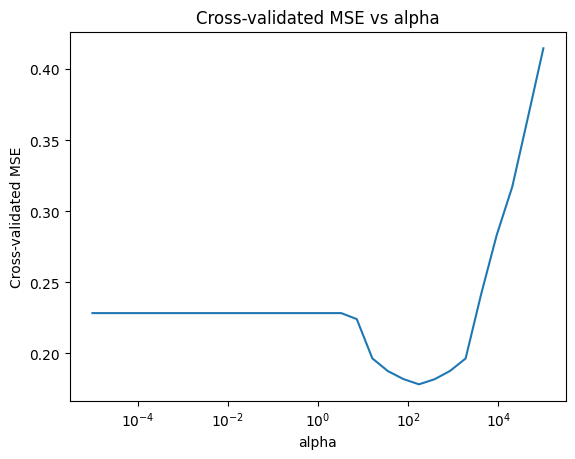

In [ ]:
#Q3.4

import matplotlib.pyplot as plt

mse_mean = lasso.mse_path_.mean(axis=1)

plt.plot(alphas, mse_mean)
plt.xscale('log')

plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-validated MSE vs alpha')

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+01, tolerance: 6.518e

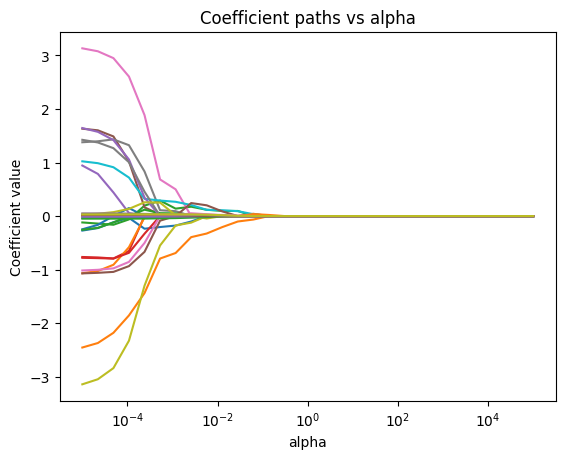

In [ ]:
#Q3.5

from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_final, y)
    coefs.append(lasso_temp.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('Coefficient paths vs alpha')

plt.show()

In [ ]:
#Q3.6

lasso_coefs = lasso.coef_
linear_coefs = model.coef_

prop_zero = np.mean(lasso_coefs == 0)

print("Proportion set to zero:", prop_zero)

for lin, las in zip(linear_coefs, lasso_coefs):
    print(f"Linear={lin:.4f}, Lasso={las:.4f}")

Proportion set to zero: 0.5862068965517241
Linear=1.5392, Lasso=-0.0000
Linear=-2.1925, Lasso=-0.3261
Linear=-0.8536, Lasso=0.1174
Linear=-3.6787, Lasso=0.0000
Linear=-0.6009, Lasso=-0.0000
Linear=1.8416, Lasso=0.0000
Linear=3.4310, Lasso=0.0000
Linear=2.6734, Lasso=0.0000
Linear=-2.6470, Lasso=-0.0000
Linear=1.9931, Lasso=0.1162
Linear=0.9080, Lasso=0.0000
Linear=-0.6975, Lasso=0.0000
Linear=-0.0812, Lasso=0.0000
Linear=-1.5777, Lasso=0.0000
Linear=1.2841, Lasso=-0.0000
Linear=-1.2503, Lasso=0.2008
Linear=-1.2700, Lasso=0.0344
Linear=1.1795, Lasso=-0.0000
Linear=0.0722, Lasso=-0.0456
Linear=0.0040, Lasso=0.0132
Linear=-0.0349, Lasso=0.0000
Linear=-0.0038, Lasso=0.0000
Linear=-0.0479, Lasso=-0.0198
Linear=0.0100, Lasso=0.0003
Linear=-0.0100, Lasso=-0.0000
Linear=0.0206, Lasso=0.0000
Linear=0.0465, Lasso=0.0245
Linear=0.0469, Lasso=0.0174
Linear=0.0305, Lasso=0.0258


**Q3.6 Answer:**

**LASSO keeps only the most important features and sets many others to zero. In this case, about 59% of the features are set to zero, so a large number of less important variables are removed.**

**Compared to linear regression, the LASSO coefficients are smaller, and many are exactly zero. No coefficients get bigger. Most keep the same sign, but a few may change slightly.**

**The LASSO model makes more sense because it removes extra noise and focuses on the most important features. In terms of bias and variance, LASSO makes the model a little simpler, which slightly increases bias but reduces variance a lot, helping the model perform better on new data.**

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

**Question 4 Work**

[Here is a Google Doc Link that has my answers to all parts of Question 4](https://docs.google.com/document/d/1LiKkYgbNL-KUPDDDclgPsp9D3J1ZBrBXFpBOPp4kRQM/edit?usp=sharing)


